In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, geom, hypergeom

np.random.seed(42)

**실습(1)-푸아송 분포**  
• 표본 평균, 표본 분산, 이론적 기댓값, 이론적 분산 출력하기  
• 히스토그램을 사용하여 푸아송 분포 시각화하기

In [ ]:
lam=4
n_samples=1000
poisson_samples=np.random.poisson(lam,size=n_samples)

In [7]:
sample_mean=np.mean(poisson_samples) #생성된 1000개 샘플의 실제 평균(표본평균)을 계산
sample_var=np.var(poisson_samples) #생성된 1000개 샘플의 실제 분산(표본분산)을 계산

theoretical_mean=lam #포아송 분포의 이론적 기댓값 공식
theoretical_var=lam #포아송 분포의 이론적 분산 공식(포아송 분포는 기댓값과 분산이 모두 람다로 동일)

print(f'표본평균: {sample_mean:.4f}')
print(f'표본분산: {sample_var:.4f}')
print(f'이론적 기댓값 E(X): {theoretical_mean:.4f}')
print(f'이론적 분산 Var(X): {theoretical_var:.4f}')

표본평균: 3.9230
표본분산: 3.9551
이론적 기댓값 E(X): 4.0000
이론적 분산 Var(X): 4.0000


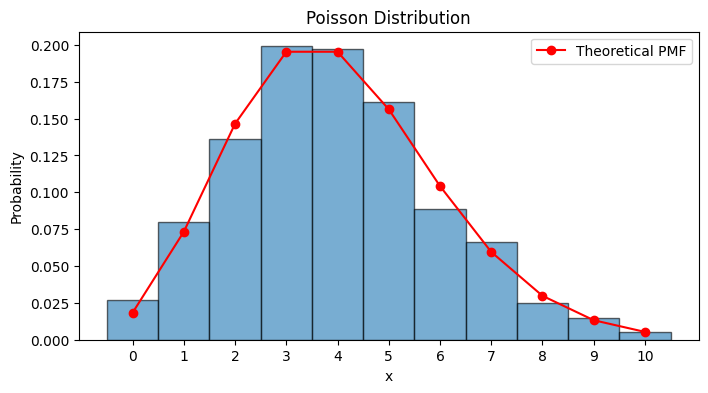

In [ ]:
x_poisson=np.arange(0, max(np.max(poisson_samples), int(poisson.ppf(0.99, mu=lam)))+1) #x축 범위 설정: 0~'샘플 데이터의 최댓값' or '이론적으로 99.9%가 되는 지점' 중 더 큰 값까지
                                                                                       #+1는 np.arange가 끝값을 포함하기 않기 때문에 끝값까지 넉넉하게 만들어주기 위함

pmf_poisson=poisson.pmf(x_poisson, mu=lam) #x값에 대한 포아송 분포의 이론적 확률 질량 함수(PMF) 값 계산

plt.figure(figsize=(8,4)) #창 크기
plt.hist(poisson_samples, 
         bins=np.arange(-0.5, x_poisson[-1]+1.5, 1), #bins=np.arange(a,b,1): a~b까지 1간격으로 숫자를 만듦
         density=True, #density=True: y축을 개수가 아니라 확률(비율)로 변환
         alpha=0.6, #alpha: 막대의 투명도
         edgecolor='black') 
                                                                                                       
                                                                                                       
plt.plot(x_poisson, pmf_poisson, 'ro-', label='Theoretical PMF') #ro-: 점과 점 사이를 직선으로 연결
plt.xticks(x_poisson) #x축에 맞춰 눈금 설정
plt.title('Poisson Distribution')
plt.xlabel('x')
plt.ylabel('Probability')
plt.legend() #범례 표시
plt.show()

**실습(2)-기하 분포**  
• 표본 평균, 표본 분산, 이론적 기댓값, 이론적 분산 출력하기  
• 히스토그램을 사용하여 기하 분포 시각화하기

In [ ]:
p=0.3
n_samples=1000
geom_samples=np.random.geometric(p, size=n_samples)

In [ ]:
sample_mean=np.mean(geom_samples) #생성된 1000개 샘플의 실제 평균(표본평균)을 계산
sample_var=np.var(geom_samples) #생성된 1000개 샘플의 실제 분산(표본분산)을 계산

theoretical_mean=1/p #기하 분포의 이론적 기댓값 공식
theoretical_var=(1-p)/(p**2) #기하 분포의 이론적 분산 공식

print(f'표본평균: {sample_mean:.4f}')
print(f'표본분산: {sample_var:.4f}')
print(f'이론적 기댓값 E(X): {theoretical_mean:.4f}')
print(f'이론적 분산 Var(X): {theoretical_var:.4f}')

표본평균: 3.3530
표본분산: 8.0084
이론적 기댓값 E(X): 3.3333
이론적 분산 Var(X): 7.7778


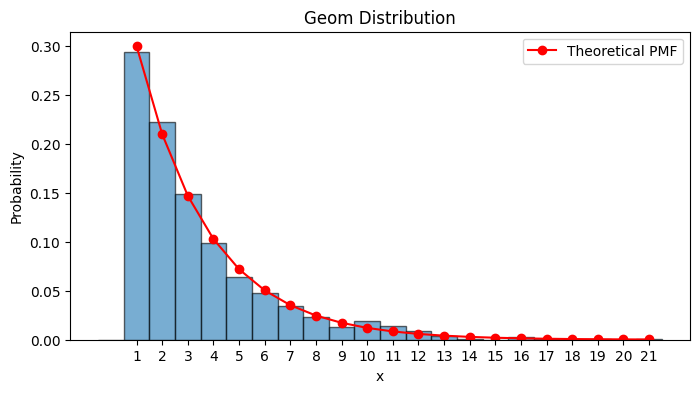

In [31]:
x_geom_max=max(np.max(geom_samples), int(geom.ppf(0.99,p))) #x축의 최댓값 설정: 샘플 데이터의 최댓값' or '이론적으로 99.9%가 되는 지점' 중 더 큰 값 선택

x_geom=np.arange(1, x_geom_max+1) #x축 범위 설정: 기하 분포는 '처음 성공할 때까지의 시도 횟수'이므로 최소 1부터 시작

pmf_geom=geom.pmf(x_geom,p) #x값에 대한 기하 분포의 이론적 확률 질량 함수(PMF) 계산

plt.figure(figsize=(8,4)) #창 크기
plt.hist(geom_samples, 
         bins=np.arange(-0.5, x_geom[-1]+1.5, 1), #bins=np.arange(a,b,1): a~b까지 1간격으로 숫자를 만듦
         density=True, #density=True: y축을 개수가 아니라 확률(비율)로 변환
         alpha=0.6, #막대의 투명도
         edgecolor='black') 
                                                                                                
plt.plot(x_geom, pmf_geom, 'ro-', label='Theoretical PMF') #ro-: 점과 점 사이를 직선으로 연결
plt.xticks(x_geom) #x축에 맞춰 눈금 설정                                                                    
plt.title('Geom Distribution')
plt.xlabel('x')
plt.ylabel('Probability')
plt.legend() #범례 표시
plt.show()

**실습(3)-초기하 분포**  
• 표본 평균, 표본 분산, 이론적 기댓값, 이론적 분산 출력하기  
• 히스토그램을 사용하여 초기하 분포 시각화하기

In [ ]:
N=50 #모집단 전체 개수
n=20 #모집단 내 성공 원소 개수
k=10 #비복원 추출 개수
n_samples=1000
hyper_samples=np.random.hypergeometric(ngood=n,nbad=N-n, nsample=k, size=n_samples)

In [ ]:
sample_mean=np.mean(hyper_samples) #생성된 1000개 샘플의 실제 평균(표본평균)을 계산
sample_var=np.var(hyper_samples) #생성된 1000개 샘플의 실제 분산(표본분산)을 계산

theoretical_mean=n*(k/N) #초기하 분포의 이론적 기댓값 공식
theoretical_var=k*(n/N)*((1-k/N)*((N-n)/(N-1))) #초기하의 이론적 분산 공식

print(f'표본평균: {sample_mean:.4f}')
print(f'표본분산: {sample_var:.4f}')
print(f'이론적 기댓값 E(X): {theoretical_mean:.4f}')
print(f'이론적 분산 Var(X): {theoretical_var:.4f}')

표본평균: 3.9020
표본분산: 1.9024
이론적 기댓값 E(X): 4.0000
이론적 분산 Var(X): 1.9592


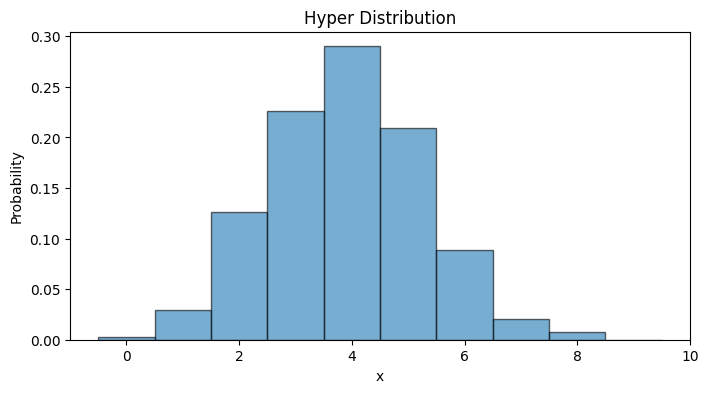

In [ ]:
plt.figure(figsize=(8,4)) #창 크기
plt.hist(hyper_samples, bins=np.arange(-0.5, 10, 1), density=True, alpha=0.6, edgecolor='black') #bins=np.arange(a,b,1): a~b까지 1간격으로 숫자를 만듦
                                                                                                 #density=True: y축을 개수가 아니라 확률(비율)로 변환
                                                                                                 #alpha: 막대의 투명도
plt.title('Hyper Distribution')
plt.xlabel('x')
plt.ylabel('Probability')
plt.show()

**실습(4)-푸아송 분포와 이항 분포의 비교**  
• 선 그래프를 사용하여 푸아송 분포와 이항분포 시각화하기

In [ ]:
#푸아송 분포와 이항 분포의 비교
n=100
p=0.3
lam=n.p